# Neuro-Symbolic Fraud Detection Notebook

## 1. Imports and Environment Setup

This section imports all required libraries and sets random seeds for reproducibility.

In [1]:
# Core data handling
import os
from pathlib import Path
import re
import math
import types
import shutil

import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Scikit-learn preprocessing and modelling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve
)

# XGBoost
from xgboost import XGBClassifier

# PyTorch neural network
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Neo4j graph database connector
from neo4j import GraphDatabase

# OWL ontology and Pellet reasoning
from owlready2 import (
    get_ontology,
    sync_reasoner_pellet,
    Thing,
    DataProperty,
    ObjectProperty,
    Imp,
    default_world,
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Use GPU if available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Project paths
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
ONTOLOGY_DIR = Path("Ontology")
OUTPUT_DIR.mkdir(exist_ok=True)


Using device: cuda


## 2. Load the IEEE-CIS Dataset

The IEEE-CIS dataset is provided as two tables:

- `train_transaction.csv`
- `train_identity.csv`

These are merged using `TransactionID`. The target variable is `isFraud`.

In [2]:
# Load the transaction and identity tables.
# Update DATA_DIR if your files are stored elsewhere.
df_transactions = pd.read_csv(DATA_DIR / "train_transaction.csv")
df_identity = pd.read_csv(DATA_DIR / "train_identity.csv")

print("Transaction table shape:", df_transactions.shape)
print("Identity table shape:", df_identity.shape)

# Merge transaction and identity data.
# Left join keeps all transactions even where identity information is missing.
df_data = df_transactions.merge(
    df_identity,
    on="TransactionID",
    how="left"
)

print("Merged dataset shape:", df_data.shape)

# Ensure TransactionID is consistently represented as a string for merging later.
df_data["TransactionID"] = df_data["TransactionID"].astype(str)

# Basic fraud distribution.
fraud_counts = df_data["isFraud"].value_counts()
fraud_rate = df_data["isFraud"].mean()

print("\nFraud counts:")
print(fraud_counts)
print(f"\nFraud rate: {fraud_rate:.4%}")

Transaction table shape: (590540, 394)
Identity table shape: (144233, 41)
Merged dataset shape: (590540, 434)

Fraud counts:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.4990%


## 3. Initial Dataset Inspection

This section provides basic checks for missing values, target distribution and available columns.

These cells are useful for the dissertation because they justify preprocessing decisions such as imputation and class-imbalance handling.

In [3]:
# Display the first few rows.
df_data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [4]:
# Show columns with the highest missingness.
missing_summary = (
    df_data.isna()
    .mean()
    .sort_values(ascending=False)
    .head(30)
)

missing_summary

id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
id_03    0.887689
id_04    0.887689
D6       0.876068
id_33    0.875895
id_10    0.873123
id_09    0.873123
D9       0.873123
D8       0.873123
id_30    0.868654
id_32    0.868619
id_34    0.868248
id_14    0.864456
V142     0.861237
V158     0.861237
V140     0.861237
dtype: float64

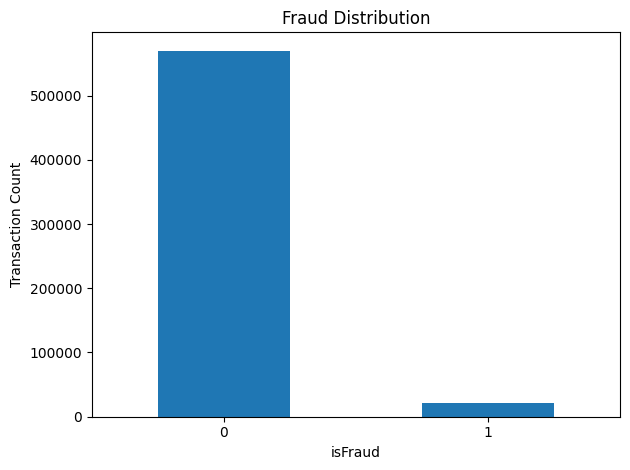

In [5]:
# Visualise the class imbalance.
df_data["isFraud"].value_counts().plot(kind="bar")
plt.title("Fraud Distribution")
plt.xlabel("isFraud")
plt.ylabel("Transaction Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Train/Test Split Before Feature Engineering

This is the most important methodological correction.

The split is performed **before**:

- graph risk feature engineering,
- ontology feature generation,
- imputation,
- encoding,
- scaling,
- model training.

This reduces the risk of test-set information leaking into the training process.

In [6]:
# Define target.
TARGET = "isFraud"

# Split the raw merged dataset.
# Stratification preserves the fraud/non-fraud ratio in both sets.
train_df, test_df = train_test_split(
    df_data,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df_data[TARGET]
)

# Reset indexes for cleaner downstream processing.
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

y_train = train_df[TARGET].astype(int)
y_test = test_df[TARGET].astype(int)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train shape: (472432, 434)
Test shape: (118108, 434)

Train fraud rate: 0.03498916246147594
Test fraud rate: 0.0349933958749619


## 5. Define Baseline Features

In [7]:
# Candidate baseline features.
# The list includes conventional transaction and identity variables available at transaction time.
candidate_baseline_features = [
    # Transaction-level features
    "TransactionAmt",
    "TransactionDT",
    "ProductCD",

    # Card features
    "card1", "card2", "card3", "card4", "card5", "card6",

    # Address and distance features
    "addr1", "addr2", "dist1", "dist2",

    # Email domains
    "P_emaildomain", "R_emaildomain",

    # Device and identity features
    "DeviceType", "DeviceInfo",
    "id_01", "id_02", "id_03", "id_04", "id_05", "id_06",
    "id_07", "id_08", "id_09", "id_10", "id_11",
    "id_12", "id_13", "id_14", "id_15", "id_16", "id_17",
    "id_18", "id_19", "id_20", "id_21", "id_22", "id_23",
    "id_24", "id_25", "id_26", "id_27", "id_28", "id_29",

    # OS, browser and screen resolution
    "id_30", "id_31", "id_32", "id_33", "id_34", "id_35",
    "id_36", "id_37", "id_38"
]

# Keep only features that actually exist in the merged dataset.
baseline_features = [col for col in candidate_baseline_features if col in df_data.columns]

print(f"Number of baseline features available: {len(baseline_features)}")
print(baseline_features)

Number of baseline features available: 55
['TransactionAmt', 'TransactionDT', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'DeviceInfo', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']


## 6. Leakage-Safe Preprocessing Utilities

Imputation, encoding and scaling must be fitted on the training set only.

The helper function below builds a preprocessing pipeline for a given feature set and returns transformed train/test matrices.

In [8]:
def split_feature_types(df, feature_cols):
    """Separate selected features into numeric and categorical columns."""
    numeric_cols = [
        col for col in feature_cols
        if pd.api.types.is_numeric_dtype(df[col])
    ]

    categorical_cols = [
        col for col in feature_cols
        if col not in numeric_cols
    ]

    return numeric_cols, categorical_cols


def build_preprocessed_matrices(train_df, test_df, feature_cols, scale_numeric=False):
    """
    Fit preprocessing on train only and transform both train and test.

    Parameters
    ----------
    train_df, test_df:
        Raw split dataframes.
    feature_cols:
        Columns to use as model inputs.
    scale_numeric:
        Whether to standardise numeric columns. Useful for neural networks.

    Returns
    -------
    X_train, X_test:
        Preprocessed numpy arrays.
    preprocessor:
        Fitted ColumnTransformer.
    feature_names:
        Names of transformed features.
    """
    numeric_cols, categorical_cols = split_feature_types(train_df, feature_cols)

    # Numeric preprocessing: impute missing values using train-set median.
    if scale_numeric:
        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ])

    # Categorical preprocessing:
    # - Missing values are treated as a separate category.
    # - Unknown categories in the test set are encoded as -1.
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
        ("encoder", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    X_train = preprocessor.fit_transform(train_df[feature_cols])
    X_test = preprocessor.transform(test_df[feature_cols])

    feature_names = numeric_cols + categorical_cols

    return X_train, X_test, preprocessor, feature_names

## 7. Baseline Dataset Preparation

This prepares the baseline feature matrices used by Random Forest, XGBoost and the neural network.

Tree-based models use unscaled numeric features.  
The neural network uses scaled numeric features.

In [9]:
# Baseline matrices for tree-based models.
Xb_train, Xb_test, baseline_preprocessor, baseline_feature_names = build_preprocessed_matrices(
    train_df=train_df,
    test_df=test_df,
    feature_cols=baseline_features,
    scale_numeric=False
)

# Baseline matrices for neural network.
Xb_train_nn, Xb_test_nn, baseline_nn_preprocessor, baseline_nn_feature_names = build_preprocessed_matrices(
    train_df=train_df,
    test_df=test_df,
    feature_cols=baseline_features,
    scale_numeric=True
)

print("Baseline train matrix:", Xb_train.shape)
print("Baseline test matrix:", Xb_test.shape)

Baseline train matrix: (472432, 55)
Baseline test matrix: (118108, 55)


## 8. Leakage-Safe Graph-Inspired Feature Engineering

This section creates graph-inspired relational features using training labels only.

For each entity column, the training set is used to calculate:

- how often each entity appears,
- how many fraud cases are associated with that entity,
- the historical fraud rate of the entity.

These mappings are then applied to both train and test.  
Unseen test entities receive neutral/default values.
This avoids the key leakage issue that test labels are never used to construct entity-risk features.

In [10]:
# Entity columns used to create relational risk features.
# These correspond to entities that can connect transactions through shared infrastructure.
candidate_entity_cols = [
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2",
    "P_emaildomain", "R_emaildomain",
    "DeviceType", "DeviceInfo",
    "id_30", "id_31", "id_33"
]

entity_cols = [col for col in candidate_entity_cols if col in df_data.columns]
print("Entity columns used for graph-inspired features:")
print(entity_cols)


def build_entity_stats(train_df, entity_cols, target_col="isFraud", min_count=5):
    """
    Build train-only entity fraud statistics.

    Each entity column is converted into a lookup table of:
    - transaction count
    - fraud count
    - fraud rate

    The lookup is fitted only on the training data.
    """
    stats = {}

    for col in entity_cols:
        temp = train_df[[col, target_col]].copy()
        temp[col] = temp[col].astype("string").fillna("__missing__")

        col_stats = (
            temp
            .groupby(col)[target_col]
            .agg(["count", "sum", "mean"])
            .rename(columns={
                "count": f"{col}_entity_count",
                "sum": f"{col}_entity_fraud_count",
                "mean": f"{col}_entity_fraud_rate"
            })
        )

        # Low-frequency entities are noisy.
        # Their fraud rate is set to neutral later by treating them as unknown.
        col_stats = col_stats[col_stats[f"{col}_entity_count"] >= min_count]

        stats[col] = col_stats

    return stats


def apply_entity_stats(df, entity_stats, entity_cols):
    """
    Apply train-derived entity statistics to a dataframe.

    Missing or unseen entities are assigned:
    - count = 0
    - fraud count = 0
    - fraud rate = 0
    """
    out = df[["TransactionID"]].copy()

    fraud_rate_cols = []
    count_cols = []

    for col in entity_cols:
        values = df[col].astype("string").fillna("__missing__")

        col_stats = entity_stats[col]

        fraud_rate_name = f"{col}_entity_fraud_rate"
        count_name = f"{col}_entity_count"

        out[fraud_rate_name] = values.map(col_stats[fraud_rate_name]).fillna(0).astype(float)
        out[count_name] = values.map(col_stats[count_name]).fillna(0).astype(float)

        fraud_rate_cols.append(fraud_rate_name)
        count_cols.append(count_name)

    # Row-level graph-inspired summaries.
    out["max_entity_fraud_rate"] = out[fraud_rate_cols].max(axis=1)
    out["mean_entity_fraud_rate"] = out[fraud_rate_cols].mean(axis=1)
    out["high_risk_entity_count"] = (out[fraud_rate_cols] >= 0.50).sum(axis=1)

    # Reuse/connectivity-style features.
    out["max_entity_frequency"] = out[count_cols].max(axis=1)
    out["mean_entity_frequency"] = out[count_cols].mean(axis=1)
    out["known_entity_count"] = (out[count_cols] > 0).sum(axis=1)

    return out

Entity columns used for graph-inspired features:
['card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'DeviceInfo', 'id_30', 'id_31', 'id_33']


In [11]:
# Fit entity statistics on training data only.
entity_stats = build_entity_stats(
    train_df=train_df,
    entity_cols=entity_cols,
    target_col=TARGET,
    min_count=5
)

# Apply train-derived mappings to train and test.
train_graph_features = apply_entity_stats(train_df, entity_stats, entity_cols)
test_graph_features = apply_entity_stats(test_df, entity_stats, entity_cols)

print("Train graph features:", train_graph_features.shape)
print("Test graph features:", test_graph_features.shape)

train_graph_features.head()

Train graph features: (472432, 37)
Test graph features: (118108, 37)


,TransactionID,card1_entity_fraud_rate,card1_entity_count,card2_entity_fraud_rate,card2_entity_count,card3_entity_fraud_rate,card3_entity_count,card4_entity_fraud_rate,card4_entity_count,card5_entity_fraud_rate,...,id_31_entity_fraud_rate,id_31_entity_count,id_33_entity_fraud_rate,id_33_entity_count,max_entity_fraud_rate,mean_entity_fraud_rate,high_risk_entity_count,max_entity_frequency,mean_entity_frequency,known_entity_count
0,3027809,0.000000,14.0,0.030266,5749.0,0.024559,416873.0,0.030339,6658.0,0.020295,...,0.019141,7262.0,0.028833,13526.0,0.066942,0.028414,0,416873.0,76636.333333,15
1,3272886,0.022624,221.0,0.018587,269.0,0.024559,416873.0,0.034293,151547.0,0.038621,...,0.021167,359907.0,0.033517,413642.0,0.043590,0.026606,0,416873.0,258378.133333,15
2,3091256,0.040650,246.0,0.021633,36195.0,0.024559,416873.0,0.034734,307711.0,0.029556,...,0.021167,359907.0,0.033517,413642.0,0.066942,0.029767,0,416873.0,255634.533333,15
3,3494860,0.072159,3520.0,0.088724,4035.0,0.024559,416873.0,0.077944,5273.0,0.063053,...,0.021167,359907.0,0.033517,413642.0,0.088724,0.042316,0,416873.0,224520.600000,15
4,3183382,0.026119,804.0,0.024173,3475.0,0.024559,416873.0,0.034734,307711.0,0.029556,...,0.021167,359907.0,0.033517,413642.0,0.034734,0.026498,0,416873.0,273937.400000,15


In [12]:
# Save leakage-safe label-derived risk features from Section 8.
# These are computed from train-derived entity statistics, not Neo4j.

label_risk_cols = [
    "max_entity_fraud_rate",
    "high_risk_entity_count",
]

fraud_rate_cols = [
    c for c in train_graph_features.columns
    if c.endswith("_entity_fraud_rate")
]

if not fraud_rate_cols:
    raise RuntimeError("No *_entity_fraud_rate columns found. This cell must be run immediately after Section 8, before the Neo4j structural feature cell.")

train_graph_features["max_entity_fraud_rate"] = train_graph_features[fraud_rate_cols].max(axis=1)
test_graph_features["max_entity_fraud_rate"] = test_graph_features[fraud_rate_cols].max(axis=1)

train_graph_features["high_risk_entity_count"] = (
    train_graph_features[fraud_rate_cols] >= 0.50
).sum(axis=1)

test_graph_features["high_risk_entity_count"] = (
    test_graph_features[fraud_rate_cols] >= 0.50
).sum(axis=1)

train_label_risk_features = train_graph_features[
    ["TransactionID"] + label_risk_cols
].copy()

test_label_risk_features = test_graph_features[
    ["TransactionID"] + label_risk_cols
].copy()

print("Saved train-only label-risk features:")
print(train_label_risk_features.head())

Saved train-only label-risk features:
  TransactionID  max_entity_fraud_rate  high_risk_entity_count
0       3027809               0.066942                       0
1       3272886               0.043590                       0
2       3091256               0.066942                       0
3       3494860               0.088724                       0
4       3183382               0.034734                       0


## 9. Neo4j Structural Graph Feature Extraction

This section restores the original project logic: structural graph features are pulled directly from Neo4j and merged into the fixed train/test split.

The notebook now require these Neo4j features to be available. This uses PageRank, degree centrality and Louvain/community-based graph features.

Expected Neo4j transaction properties:

- `transaction_id`
- `communityId`
- `pagerank`
- `degree`
- `max_entity_fraud_rate`
- `high_risk_entity_count`

Set the following environment variables if your Neo4j details differ from the defaults:

- `NEO4J_URI`
- `NEO4J_USER`
- `NEO4J_PASSWORD`
- `NEO4J_DATABASE`


In [13]:
# Neo4j connection details. Defaults match the original project notebook.
NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "fraudgraph")
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE", "fraudgraph")

# These match the graph-derived fields used in the original project notebook.
structural_graph_cols = [
    "community_id",
    "pagerank",
    "degree"
]

neo4j_feature_query = """
MATCH (t:Transaction)
RETURN
  toString(coalesce(t.transaction_id, t.TransactionID, t.TransactionId)) AS TransactionID,
  coalesce(t.communityId, t.community_id) AS community_id,
  t.pagerank AS pagerank,
  t.degree AS degree
"""

driver = None

try:
    driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
    with driver.session(database=NEO4J_DATABASE) as session:
        result = session.run(neo4j_feature_query)
        neo4j_graph_features = pd.DataFrame([record.data() for record in result])
finally:
    if driver is not None:
        driver.close()

# ------------------------------------------------------------
# Validate Neo4j output
# ------------------------------------------------------------

if neo4j_graph_features.empty:
    raise RuntimeError(
        "Neo4j returned no Transaction graph features. "
        "Check that the fraudgraph database exists and that Transaction nodes contain "
        "transaction_id/TransactionID, communityId, pagerank, degree, "
        "max_entity_fraud_rate, and high_risk_entity_count."
    )

missing_cols = [
    c for c in ["TransactionID"] + structural_graph_cols
    if c not in neo4j_graph_features.columns
]

if missing_cols:
    raise RuntimeError(
        f"Neo4j graph feature query is missing expected columns: {missing_cols}"
    )

# Normalise TransactionID for safe merging.
neo4j_graph_features["TransactionID"] = neo4j_graph_features["TransactionID"].astype(str)

# Drop invalid TransactionIDs.
neo4j_graph_features = neo4j_graph_features[
    neo4j_graph_features["TransactionID"].notna()
    & (neo4j_graph_features["TransactionID"] != "None")
    & (neo4j_graph_features["TransactionID"] != "nan")
].copy()

# Ensure one row per transaction.
duplicate_count = neo4j_graph_features["TransactionID"].duplicated().sum()

if duplicate_count > 0:
    print(f"Warning: {duplicate_count} duplicate TransactionID rows found in Neo4j output. Keeping first occurrence.")
    neo4j_graph_features = neo4j_graph_features.drop_duplicates(
        subset=["TransactionID"],
        keep="first"
    )

# Numeric cleanup.
for col in structural_graph_cols:
    neo4j_graph_features[col] = pd.to_numeric(
        neo4j_graph_features[col],
        errors="coerce"
    )

# ------------------------------------------------------------
# Rebuild train/test graph feature tables directly from Neo4j
# This avoids pandas suffixes such as _x and _y.
# ------------------------------------------------------------

train_df["TransactionID"] = train_df["TransactionID"].astype(str)
test_df["TransactionID"] = test_df["TransactionID"].astype(str)

train_graph_features = train_df[["TransactionID"]].merge(
    neo4j_graph_features[["TransactionID"] + structural_graph_cols],
    on="TransactionID",
    how="left"
)

test_graph_features = test_df[["TransactionID"]].merge(
    neo4j_graph_features[["TransactionID"] + structural_graph_cols],
    on="TransactionID",
    how="left"
)

# ------------------------------------------------------------
# Validate merge coverage before filling missing values
# ------------------------------------------------------------

train_missing = train_graph_features[structural_graph_cols].isna().mean().sort_values(ascending=False)
test_missing = test_graph_features[structural_graph_cols].isna().mean().sort_values(ascending=False)

print("Neo4j structural graph features loaded:")
print(neo4j_graph_features[["TransactionID"] + structural_graph_cols].head())

print("\nTrain missing-rate by Neo4j graph feature:")
print(train_missing)

print("\nTest missing-rate by Neo4j graph feature:")
print(test_missing)

if train_missing.max() > 0.05 or test_missing.max() > 0.05:
    raise RuntimeError(
        "More than 5% of rows failed to merge with Neo4j structural graph features. "
        "Check TransactionID consistency between the CSV data and Neo4j."
    )

# Fill occasional missing graph values.
for col in structural_graph_cols:
    train_graph_features[col] = (
        train_graph_features[col]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )
    test_graph_features[col] = (
        test_graph_features[col]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

# Make downstream naming explicit.
graph_feature_cols = structural_graph_cols.copy()

print("\nFinal train graph feature table:", train_graph_features.shape)
print("Final test graph feature table:", test_graph_features.shape)
print("Graph feature columns:", graph_feature_cols)

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `TransactionID` does not exist in database `fraudgraph`. Verify that the spelling is correct.', position=<SummaryInputPosition line=4, column=41, offset=70>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 70, 'line': 4, 'column': 41}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (t:Transaction)\nRETURN\n  toString(coalesce(t.transaction_id, t.TransactionID, t.TransactionId)) AS TransactionID,\n  coalesce(t.communityId, t.community_id) AS community_id,\n  t.pagerank AS pagerank,\n  t.degree AS degree\n'
Received notification from DBMS server: <GqlStatusObject gql_status=

Neo4j structural graph features loaded:
  TransactionID  community_id  pagerank  degree
0       2987000           283  0.437509       8
1       2987001           283  0.505149      10
2       2987002           355  0.509034      10
3       2987003          1684  0.510705      10
4       2987004           283  0.680552      15

Train missing-rate by Neo4j graph feature:
community_id    0.0
pagerank        0.0
degree          0.0
dtype: float64

Test missing-rate by Neo4j graph feature:
community_id    0.0
pagerank        0.0
degree          0.0
dtype: float64

Final train graph feature table: (472432, 4)
Final test graph feature table: (118108, 4)
Graph feature columns: ['community_id', 'pagerank', 'degree']


In [15]:
# ============================================================
# Merge original Neo4j graph features back into fixed train/test splits
# ============================================================


required_cols = ["TransactionID"] + structural_graph_cols

missing_train_graph_cols = [c for c in required_cols if c not in train_graph_features.columns]
missing_test_graph_cols = [c for c in required_cols if c not in test_graph_features.columns]

if missing_train_graph_cols:
    raise RuntimeError(f"train_graph_features is missing columns: {missing_train_graph_cols}")

if missing_test_graph_cols:
    raise RuntimeError(f"test_graph_features is missing columns: {missing_test_graph_cols}")

# Keep only the original Neo4j graph features.
train_graph_features = train_graph_features[required_cols].copy()
test_graph_features = test_graph_features[required_cols].copy()

# Normalise TransactionID type.
train_df["TransactionID"] = train_df["TransactionID"].astype(str)
test_df["TransactionID"] = test_df["TransactionID"].astype(str)
train_graph_features["TransactionID"] = train_graph_features["TransactionID"].astype(str)
test_graph_features["TransactionID"] = test_graph_features["TransactionID"].astype(str)

# Drop any existing graph feature columns from train/test before merging.
# This prevents pandas from creating _x / _y suffix columns.
train_base_for_graph = train_df.drop(
    columns=[c for c in structural_graph_cols if c in train_df.columns],
    errors="ignore"
).copy()

test_base_for_graph = test_df.drop(
    columns=[c for c in structural_graph_cols if c in test_df.columns],
    errors="ignore"
).copy()

# Merge graph features into the fixed train/test splits.
train_graph_df = train_base_for_graph.merge(
    train_graph_features,
    on="TransactionID",
    how="left"
)

test_graph_df = test_base_for_graph.merge(
    test_graph_features,
    on="TransactionID",
    how="left"
)

# Use exactly the original Neo4j graph feature set.
graph_features = structural_graph_cols.copy()

# Confirm that the core Neo4j features described in the report are present.
missing_required_graph_features = [
    c for c in graph_features
    if c not in train_graph_df.columns or c not in test_graph_df.columns
]

if missing_required_graph_features:
    raise RuntimeError(
        f"Core Neo4j graph features missing from graph model: {missing_required_graph_features}"
    )

# Fill any missing graph values with neutral/default values.
for col in graph_features:
    train_graph_df[col] = (
        train_graph_df[col]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )
    test_graph_df[col] = (
        test_graph_df[col]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

# Final graph-enhanced model feature list.
graph_enhanced_features = list(dict.fromkeys(baseline_features + graph_features))

# Validate that all graph-enhanced features exist in both train and test.
missing_train_model_cols = [c for c in graph_enhanced_features if c not in train_graph_df.columns]
missing_test_model_cols = [c for c in graph_enhanced_features if c not in test_graph_df.columns]

if missing_train_model_cols:
    raise RuntimeError(f"train_graph_df is missing graph-enhanced model columns: {missing_train_model_cols}")

if missing_test_model_cols:
    raise RuntimeError(f"test_graph_df is missing graph-enhanced model columns: {missing_test_model_cols}")

print(f"Number of graph features: {len(graph_features)}")
print(f"Total graph-enhanced features: {len(graph_enhanced_features)}")
print("Core Neo4j graph features included:", graph_features)
print("train_graph_df shape:", train_graph_df.shape)
print("test_graph_df shape:", test_graph_df.shape)

Number of graph features: 3
Total graph-enhanced features: 58
Core Neo4j graph features included: ['community_id', 'pagerank', 'degree']
train_graph_df shape: (472432, 437)
test_graph_df shape: (118108, 437)


## 10. Build Graph-Enhanced Dataset

Graph-derived features are merged back into the fixed train/test split.

This produces the second experimental condition:

1. Baseline features only.
2. Baseline + graph-derived features.

In [16]:
# Merge leakage-safe label-derived risk features back after Neo4j structural merge.

label_risk_cols = [
    "max_entity_fraud_rate",
    "high_risk_entity_count",
]

train_graph_df = train_graph_df.drop(columns=label_risk_cols, errors="ignore")
test_graph_df = test_graph_df.drop(columns=label_risk_cols, errors="ignore")

train_graph_df = train_graph_df.merge(
    train_label_risk_features[["TransactionID"] + label_risk_cols],
    on="TransactionID",
    how="left"
)

test_graph_df = test_graph_df.merge(
    test_label_risk_features[["TransactionID"] + label_risk_cols],
    on="TransactionID",
    how="left"
)

for col in label_risk_cols:
    train_graph_df[col] = train_graph_df[col].fillna(0)
    test_graph_df[col] = test_graph_df[col].fillna(0)

graph_features = [
    "community_id",
    "pagerank",
    "degree",
    "max_entity_fraud_rate",
    "high_risk_entity_count",
]

graph_enhanced_features = list(dict.fromkeys(baseline_features + graph_features))

print("Final graph features:", graph_features)
print("Total graph-enhanced features:", len(graph_enhanced_features))

Final graph features: ['community_id', 'pagerank', 'degree', 'max_entity_fraud_rate', 'high_risk_entity_count']
Total graph-enhanced features: 60


In [17]:
# Graph-enhanced matrices for tree-based models.
Xg_train, Xg_test, graph_preprocessor, graph_feature_names = build_preprocessed_matrices(
    train_df=train_graph_df,
    test_df=test_graph_df,
    feature_cols=graph_enhanced_features,
    scale_numeric=False
)

# Graph-enhanced matrices for neural network.
Xg_train_nn, Xg_test_nn, graph_nn_preprocessor, graph_nn_feature_names = build_preprocessed_matrices(
    train_df=train_graph_df,
    test_df=test_graph_df,
    feature_cols=graph_enhanced_features,
    scale_numeric=True
)

print("Graph-enhanced train matrix:", Xg_train.shape)
print("Graph-enhanced test matrix:", Xg_test.shape)

Graph-enhanced train matrix: (472432, 60)
Graph-enhanced test matrix: (118108, 60)


## 11. Pellet Reasoning and Ontology-Derived Semantic Features

The process is:

1. Load the OWL ontology developed in Protégé.
2. Populate transaction individuals with graph-derived properties such as PageRank, degree, community ID, maximum linked entity fraud rate and high-risk entity count.
3. Add executable SWRL-style rules.
4. Run Pellet reasoning through `owlready2.sync_reasoner_pellet`.
5. Extract inferred class memberships such as `SemanticallySuspiciousTransaction`, `StronglySuspiciousTransaction`, and `RequiresInvestigation`.
6. Merge these Pellet-derived flags back into the machine-learning feature tables.

By default the notebook reasons over the full train/test dataset. If this is too slow on your machine, set `PELLET_REASONING_LIMIT` as an environment variable during development, this is limited to 10000 for perfomance reasons.


In [18]:
# Restore train-only label-derived graph-risk features after Neo4j structural merge.
# These must come from the leakage-safe Section 8 feature engineering, not Neo4j.

label_risk_cols = [
    "max_entity_fraud_rate",
    "high_risk_entity_count",
]

missing_train_label_risk = [
    c for c in label_risk_cols
    if c not in train_label_risk_features.columns
]

missing_test_label_risk = [
    c for c in label_risk_cols
    if c not in test_label_risk_features.columns
]

if missing_train_label_risk:
    raise RuntimeError(f"train_label_risk_features missing: {missing_train_label_risk}")

if missing_test_label_risk:
    raise RuntimeError(f"test_label_risk_features missing: {missing_test_label_risk}")

# Remove any stale versions before merging.
train_graph_df = train_graph_df.drop(columns=label_risk_cols, errors="ignore")
test_graph_df = test_graph_df.drop(columns=label_risk_cols, errors="ignore")

train_graph_df = train_graph_df.merge(
    train_label_risk_features[["TransactionID"] + label_risk_cols],
    on="TransactionID",
    how="left"
)

test_graph_df = test_graph_df.merge(
    test_label_risk_features[["TransactionID"] + label_risk_cols],
    on="TransactionID",
    how="left"
)

for col in label_risk_cols:
    train_graph_df[col] = train_graph_df[col].fillna(0)
    test_graph_df[col] = test_graph_df[col].fillna(0)

graph_features = [
    "community_id",
    "pagerank",
    "degree",
    "max_entity_fraud_rate",
    "high_risk_entity_count",
]

graph_enhanced_features = list(dict.fromkeys(baseline_features + graph_features))

print("Final graph features:", graph_features)
print("Total graph-enhanced features:", len(graph_enhanced_features))

Final graph features: ['community_id', 'pagerank', 'degree', 'max_entity_fraud_rate', 'high_risk_entity_count']
Total graph-enhanced features: 60


In [19]:
from pathlib import Path
import shutil
import subprocess
import owlready2

possible_roots = [
    Path(r"C:\Program Files\Java")
]

java_candidates = []

# First check PATH
path_java = shutil.which("java")
if path_java:
    java_candidates.append(Path(path_java))

# Then search common install folders
for root in possible_roots:
    if root.exists():
        java_candidates.extend(root.glob(r"**\bin\java.exe"))

print("Java candidates found:")
for i, p in enumerate(java_candidates):
    print(i, p)

if not java_candidates:
    raise FileNotFoundError(
        "No java.exe found."
    )

# Use the first found Java executable
java_exe = str(java_candidates[0])
owlready2.JAVA_EXE = java_exe
owlready2.JAVA_MEMORY = 24000

print("\nUsing Java:", owlready2.JAVA_EXE)
print("Pellet memory:", owlready2.JAVA_MEMORY, "MB")

result = subprocess.run(
    [owlready2.JAVA_EXE, "-version"],
    capture_output=True,
    text=True
)

print(result.stderr or result.stdout)

Java candidates found:
0 C:\Program Files\Java\jdk-25.0.3\bin\java.exe
1 C:\Program Files\Java\latest\jdk-25\bin\java.exe

Using Java: C:\Program Files\Java\jdk-25.0.3\bin\java.exe
Pellet memory: 24000 MB
java version "25.0.3" 2026-04-21 LTS
Java(TM) SE Runtime Environment (build 25.0.3+9-LTS-195)
Java HotSpot(TM) 64-Bit Server VM (build 25.0.3+9-LTS-195, mixed mode, sharing)



In [20]:
# Thresholds aligned with the ontology/SWRL rule logic.
ENTITY_HIGH_RISK_THRESHOLD = 0.50
HIGH_RISK_ENTITY_COUNT_THRESHOLD = 2
COMMUNITY_HIGH_RISK_THRESHOLD = 0.05

# Locate the ontology file. The first existing path is used.
ontology_candidates = [
    ONTOLOGY_DIR / "fraud_detection_ontology.owl",
    ONTOLOGY_DIR / "fraud_detection_ontology.owx",
    Path("fraud_detection_ontology.owl"),
    Path("fraud_detection_ontology.owx"),
]

ontology_path = next((p for p in ontology_candidates if p.exists()), None)
if ontology_path is None:
    raise FileNotFoundError(
        "Could not find the fraud detection ontology. Expected one of: "
        + ", ".join(str(p) for p in ontology_candidates)
    )

print("Loading ontology:", ontology_path)
onto = get_ontology(str(ontology_path.resolve())).load()


def safe_name(value):
    """Create a safe OWL individual name from an arbitrary value."""
    value = str(value)
    value = re.sub(r"[^A-Za-z0-9_]", "_", value)
    return value[:100]


def is_valid(value):
    """Return True for usable scalar values."""
    if value is None:
        return False
    try:
        if pd.isna(value):
            return False
    except Exception:
        pass
    return True


def ensure_class(name, parent=Thing):
    """Return an ontology class, creating it if absent."""
    existing = getattr(onto, name, None)
    if existing is not None:
        return existing
    with onto:
        return types.new_class(name, (parent,))


def ensure_data_property(name):
    """Return an ontology data property, creating it if absent."""
    existing = getattr(onto, name, None)
    if existing is not None:
        return existing
    with onto:
        return types.new_class(name, (DataProperty,))


def ensure_object_property(name):
    """Return an ontology object property, creating it if absent."""
    existing = getattr(onto, name, None)
    if existing is not None:
        return existing
    with onto:
        return types.new_class(name, (ObjectProperty,))


# Ensure the classes/properties used by the reasoning pipeline exist.
with onto:
    Transaction = ensure_class("Transaction")
    SemanticallySuspiciousTransaction = ensure_class("SemanticallySuspiciousTransaction", Transaction)
    StronglySuspiciousTransaction = ensure_class("StronglySuspiciousTransaction", SemanticallySuspiciousTransaction)
    RequiresInvestigation = ensure_class("RequiresInvestigation", Transaction)
    Device = ensure_class("Device")
    HighRiskDevice = ensure_class("HighRiskDevice", Device)
    Community = ensure_class("Community")
    HighRiskCommunity = ensure_class("HighRiskCommunity", Community)

    transactionId = ensure_data_property("transactionId")
    isFraud = ensure_data_property("isFraud")
    transactionAmount = ensure_data_property("transactionAmount")
    transactionDatetime = ensure_data_property("transactionDatetime")
    communityId = ensure_data_property("communityId")
    pageRank = ensure_data_property("pageRank")
    degree = ensure_data_property("degree")
    maxEntityFraudRate = ensure_data_property("maxEntityFraudRate")
    highRiskEntityCount = ensure_data_property("highRiskEntityCount")
    ontologyRiskScore = ensure_data_property("ontologyRiskScore")
    usedDevice = ensure_object_property("usedDevice")
    belongsToCommunity = ensure_object_property("belongsToCommunity")

# Add executable SWRL rules that mirror the report's semantic reasoning.
# Rules are only created if they are not already present in the ontology.
existing_rule_names = {getattr(rule, "name", "") for rule in onto.rules()}

with onto:
    if "Rule_HighEntityFraudRate_ImpliesSemanticSuspicion" not in existing_rule_names:
        rule = Imp("Rule_HighEntityFraudRate_ImpliesSemanticSuspicion")
        rule.set_as_rule(
            "Transaction(?t), maxEntityFraudRate(?t, ?r), greaterThanOrEqual(?r, 0.5) -> SemanticallySuspiciousTransaction(?t)"
        )

    if "Rule_MultipleHighRiskEntities_ImpliesStrongSuspicion" not in existing_rule_names:
        rule = Imp("Rule_MultipleHighRiskEntities_ImpliesStrongSuspicion")
        rule.set_as_rule(
            "Transaction(?t), highRiskEntityCount(?t, ?c), greaterThanOrEqual(?c, 2) -> StronglySuspiciousTransaction(?t)"
        )

    if "Rule_StrongSuspicion_RequiresInvestigation" not in existing_rule_names:
        rule = Imp("Rule_StrongSuspicion_RequiresInvestigation")
        rule.set_as_rule(
            "StronglySuspiciousTransaction(?t) -> RequiresInvestigation(?t)"
        )

# Prepare rows for Pellet reasoning.
reasoning_df = pd.concat([
    train_graph_df.assign(_split="train"),
    test_graph_df.assign(_split="test")
], ignore_index=True)

limit_raw = os.getenv("PELLET_REASONING_LIMIT", "10000")
if str(limit_raw).upper() != "ALL":
    limit = int(limit_raw)
    high_risk_mask = (
        (reasoning_df["max_entity_fraud_rate"].fillna(0) >= ENTITY_HIGH_RISK_THRESHOLD) |
        (reasoning_df["high_risk_entity_count"].fillna(0) >= HIGH_RISK_ENTITY_COUNT_THRESHOLD)
    )
    high_risk_rows = reasoning_df[high_risk_mask]
    remaining = reasoning_df[~high_risk_mask]
    if len(high_risk_rows) >= limit:
        reasoning_df = high_risk_rows.sample(limit, random_state=RANDOM_STATE)
    else:
        extra = remaining.sample(min(len(remaining), limit - len(high_risk_rows)), random_state=RANDOM_STATE)
        reasoning_df = pd.concat([high_risk_rows, extra], ignore_index=True)
    print(f"PELLET_REASONING_LIMIT={limit}; reasoning over {len(reasoning_df)} selected transactions.")
else:
    print(f"Reasoning over train/test dataset: {len(reasoning_df)} transactions.")

# Populate ontology individuals with graph-derived data properties.
for _, row in reasoning_df.iterrows():
    tx_name = "tx_" + safe_name(row["TransactionID"])
    tx = onto.Transaction(tx_name)

    tx.transactionId = [str(row["TransactionID"])]
    tx.isFraud = [int(row[TARGET])]

    if is_valid(row.get("TransactionAmt")):
        tx.transactionAmount = [float(row["TransactionAmt"])]
    if is_valid(row.get("TransactionDT")):
        tx.transactionDatetime = [float(row["TransactionDT"])]
    if is_valid(row.get("community_id")):
        tx.communityId = [int(float(row["community_id"]))]
    if is_valid(row.get("pagerank")):
        tx.pageRank = [float(row["pagerank"])]
    if is_valid(row.get("degree")):
        tx.degree = [int(float(row["degree"]))]
    if is_valid(row.get("max_entity_fraud_rate")):
        tx.maxEntityFraudRate = [float(row["max_entity_fraud_rate"])]
    if is_valid(row.get("high_risk_entity_count")):
        tx.highRiskEntityCount = [int(float(row["high_risk_entity_count"]))]

print("Ontology individuals before Pellet:", len(list(onto.individuals())))

# Run Pellet reasoning. This requires Java and owlready2's bundled Pellet support.
sync_reasoner_pellet(
    [onto],
    infer_property_values=True,
    infer_data_property_values=True,
    debug=1
)

# Extract Pellet-inferred class memberships back into a dataframe.
pellet_rows = []
for _, row in reasoning_df.iterrows():
    tx_name = "tx_" + safe_name(row["TransactionID"])
    tx = onto.search_one(iri="*" + tx_name)
    if tx is None:
        continue

    inferred_classes = set(tx.INDIRECT_is_a)
    pellet_rows.append({
        "TransactionID": str(row["TransactionID"]),
        "pellet_semantically_suspicious": int(onto.SemanticallySuspiciousTransaction in inferred_classes),
        "pellet_strongly_suspicious": int(onto.StronglySuspiciousTransaction in inferred_classes),
        "pellet_requires_investigation": int(onto.RequiresInvestigation in inferred_classes),
    })

pellet_feature_df = pd.DataFrame(pellet_rows).drop_duplicates("TransactionID")
print("Pellet-derived feature table:", pellet_feature_df.shape)
print(pellet_feature_df.head())

# Save reasoned ontology as evidence of Pellet execution.
ONTOLOGY_DIR.mkdir(exist_ok=True)
reasoned_ontology_path = ONTOLOGY_DIR / "fraud_detection_ontology_with_pellet_inferences.owl"
onto.save(file=str(reasoned_ontology_path), format="rdfxml")
print("Saved reasoned ontology:", reasoned_ontology_path)

# Merge Pellet-derived features into train/test graph dataframes.
pellet_features = [
    "pellet_semantically_suspicious",
    "pellet_strongly_suspicious",
    "pellet_requires_investigation",
]

train_graph_df = train_graph_df.merge(pellet_feature_df, on="TransactionID", how="left")
test_graph_df = test_graph_df.merge(pellet_feature_df, on="TransactionID", how="left")

for col in pellet_features:
    train_graph_df[col] = train_graph_df[col].fillna(0).astype(int)
    test_graph_df[col] = test_graph_df[col].fillna(0).astype(int)

print("Pellet feature sums in train:")
print(train_graph_df[pellet_features].sum())
print("\nPellet feature sums in test:")
print(test_graph_df[pellet_features].sum())

# Now create the final ontology-derived model features, incorporating Pellet output.
def add_ontology_features(df):
    """
    Add ontology-derived semantic features.

    The threshold-derived flags mirror the SWRL rule logic, while the pellet_* columns
    record actual Pellet-inferred class memberships. The final semantic flags combine
    both so that Pellet reasoning is explicitly represented in the ML feature matrix.
    """
    out = df.copy()

    threshold_uses_high_risk_entity = (
        out["max_entity_fraud_rate"].fillna(0) >= ENTITY_HIGH_RISK_THRESHOLD
    ).astype(int)

    threshold_multiple_high_risk = (
        out["high_risk_entity_count"].fillna(0) >= HIGH_RISK_ENTITY_COUNT_THRESHOLD
    ).astype(int)

    out["uses_high_risk_entity"] = threshold_uses_high_risk_entity
    out["has_multiple_high_risk_entities"] = threshold_multiple_high_risk

    out["semantically_suspicious"] = np.maximum(
        ((out["uses_high_risk_entity"] == 1) | (out["has_multiple_high_risk_entities"] == 1)).astype(int),
        out["pellet_semantically_suspicious"].astype(int)
    )

    out["strongly_suspicious"] = np.maximum(
        ((out["has_multiple_high_risk_entities"] == 1) | (out["max_entity_fraud_rate"].fillna(0) >= ENTITY_HIGH_RISK_THRESHOLD)).astype(int),
        out["pellet_strongly_suspicious"].astype(int)
    )

    out["requires_investigation"] = np.maximum(
        (out["strongly_suspicious"] == 1).astype(int),
        out["pellet_requires_investigation"].astype(int)
    )

    out["ontology_risk_score"] = (
        (out["max_entity_fraud_rate"].fillna(0) * 0.60) +
        (out["high_risk_entity_count"].fillna(0).clip(0, 5) / 5 * 0.30) +
        (out["pellet_requires_investigation"].fillna(0) * 0.10)
    )

    return out

train_ontology_df = add_ontology_features(train_graph_df)
test_ontology_df = add_ontology_features(test_graph_df)

ontology_features = pellet_features + [
    "uses_high_risk_entity",
    "has_multiple_high_risk_entities",
    "semantically_suspicious",
    "strongly_suspicious",
    "requires_investigation",
    "ontology_risk_score",
]

graph_ontology_features = graph_enhanced_features + ontology_features

print("Ontology-derived features used in ML:", ontology_features)
train_ontology_df[ontology_features].head()


Loading ontology: Ontology\fraud_detection_ontology.owx
PELLET_REASONING_LIMIT=10000; reasoning over 10000 selected transactions.
Ontology individuals before Pellet: 10021


* Owlready2 * Running Pellet...
    C:\Program Files\Java\jdk-25.0.3\bin\java.exe -Xmx2000M -cp C:\Users\Osman\AppData\Local\Programs\Python\Python311\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\Osman\AppData\Local\Programs\Python\Python311\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\Osman\AppData\Local\Programs\Python\Python311\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\Osman\AppData\Local\Programs\Python\Python311\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\Osman\AppData\Local\Programs\Python\Python311\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\Osman\AppData\Local\Programs\Python\Python311\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\Osman\AppData\Local\Programs\Python\Python311\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\Osman\AppData\Local\Programs\Python\Python311\Lib\site-packages\owlready2\pellet\jena-arq-fixed2.10.0.jar;C:\Users\Osman\Ap

Pellet-derived feature table: (10000, 4)
  TransactionID  pellet_semantically_suspicious  pellet_strongly_suspicious  \
0       3329264                               1                           1   
1       3201648                               1                           1   
2       3119262                               1                           1   
3       3010406                               1                           1   
4       3538388                               1                           1   

   pellet_requires_investigation  
0                              1  
1                              1  
2                              1  
3                              1  
4                              1  
Saved reasoned ontology: Ontology\fraud_detection_ontology_with_pellet_inferences.owl
Pellet feature sums in train:
pellet_semantically_suspicious    2600
pellet_strongly_suspicious        2600
pellet_requires_investigation     2600
dtype: int64

Pellet feature sums in test

,pellet_semantically_suspicious,pellet_strongly_suspicious,pellet_requires_investigation,uses_high_risk_entity,has_multiple_high_risk_entities,semantically_suspicious,strongly_suspicious,requires_investigation,ontology_risk_score
0,0,0,0,0,0,0,0,0,0.040165
1,0,0,0,0,0,0,0,0,0.026154
2,0,0,0,0,0,0,0,0,0.040165
3,0,0,0,0,0,0,0,0,0.053234
4,0,0,0,0,0,0,0,0,0.020840


In [21]:
# Graph + ontology matrices for tree-based models.
Xgo_train, Xgo_test, graph_ontology_preprocessor, graph_ontology_feature_names = build_preprocessed_matrices(
    train_df=train_ontology_df,
    test_df=test_ontology_df,
    feature_cols=graph_ontology_features,
    scale_numeric=False
)

# Graph + ontology matrices for neural network.
Xgo_train_nn, Xgo_test_nn, graph_ontology_nn_preprocessor, graph_ontology_nn_feature_names = build_preprocessed_matrices(
    train_df=train_ontology_df,
    test_df=test_ontology_df,
    feature_cols=graph_ontology_features,
    scale_numeric=True
)

print("Graph + ontology train matrix:", Xgo_train.shape)
print("Graph + ontology test matrix:", Xgo_test.shape)

Graph + ontology train matrix: (472432, 69)
Graph + ontology test matrix: (118108, 69)


## 12. Evaluation Utilities

All models are evaluated using the same metrics:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

PR-AUC is especially important because fraud detection is highly imbalanced.

In [22]:
def evaluate_predictions(y_true, probs, threshold=0.50):
    """Return standard binary classification metrics from probabilities."""
    preds = (probs >= threshold).astype(int)

    return {
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probs),
        "pr_auc": average_precision_score(y_true, probs)
    }


def print_model_report(model_name, y_true, probs, threshold=0.50):
    """Print classification report and key metrics."""
    preds = (probs >= threshold).astype(int)
    metrics = evaluate_predictions(y_true, probs, threshold=threshold)

    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(classification_report(y_true, preds, zero_division=0))
    print("ROC-AUC:", metrics["roc_auc"])
    print("PR-AUC:", metrics["pr_auc"])

    return metrics

## 13. Random Forest Models

Random Forest is used as a robust ensemble baseline for tabular fraud detection.

In [23]:
rf_params = {
    "n_estimators": 300,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

rf_baseline = RandomForestClassifier(**rf_params)
rf_graph = RandomForestClassifier(**rf_params)
rf_graph_ontology = RandomForestClassifier(**rf_params)

# Train models.
rf_baseline.fit(Xb_train, y_train)
rf_graph.fit(Xg_train, y_train)
rf_graph_ontology.fit(Xgo_train, y_train)

# Predict probabilities.
rf_baseline_probs = rf_baseline.predict_proba(Xb_test)[:, 1]
rf_graph_probs = rf_graph.predict_proba(Xg_test)[:, 1]
rf_graph_ontology_probs = rf_graph_ontology.predict_proba(Xgo_test)[:, 1]

# Evaluate.
rf_baseline_metrics = print_model_report("RF Baseline", y_test, rf_baseline_probs)
rf_graph_metrics = print_model_report("RF Graph-Enhanced", y_test, rf_graph_probs)
rf_graph_ontology_metrics = print_model_report("RF Graph + Ontology", y_test, rf_graph_ontology_probs)

RF Baseline
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.97      0.47      0.63      4133

    accuracy                           0.98    118108
   macro avg       0.98      0.73      0.81    118108
weighted avg       0.98      0.98      0.98    118108

ROC-AUC: 0.9560406949304141
PR-AUC: 0.7946766888200476
RF Graph-Enhanced
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.95      0.52      0.68      4133

    accuracy                           0.98    118108
   macro avg       0.97      0.76      0.83    118108
weighted avg       0.98      0.98      0.98    118108

ROC-AUC: 0.9582151926190512
PR-AUC: 0.805092243941509
RF Graph + Ontology
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.95      0.53      0.68      4133

    accuracy           

## 14. XGBoost Models

XGBoost is included because gradient boosting is a strong method for structured tabular classification problems.

The `scale_pos_weight` parameter is used to compensate for fraud class imbalance.

In [24]:
# Positive class weight for XGBoost.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_params = {
    "n_estimators": 300,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "scale_pos_weight": scale_pos_weight,
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

xgb_baseline = XGBClassifier(**xgb_params)
xgb_graph = XGBClassifier(**xgb_params)
xgb_graph_ontology = XGBClassifier(**xgb_params)

# Train models.
xgb_baseline.fit(Xb_train, y_train)
xgb_graph.fit(Xg_train, y_train)
xgb_graph_ontology.fit(Xgo_train, y_train)

# Predict probabilities.
xgb_baseline_probs = xgb_baseline.predict_proba(Xb_test)[:, 1]
xgb_graph_probs = xgb_graph.predict_proba(Xg_test)[:, 1]
xgb_graph_ontology_probs = xgb_graph_ontology.predict_proba(Xgo_test)[:, 1]

# Evaluate.
xgb_baseline_metrics = print_model_report("XGB Baseline", y_test, xgb_baseline_probs)
xgb_graph_metrics = print_model_report("XGB Graph-Enhanced", y_test, xgb_graph_probs)
xgb_graph_ontology_metrics = print_model_report("XGB Graph + Ontology", y_test, xgb_graph_ontology_probs)

scale_pos_weight: 27.580278281911674
XGB Baseline
              precision    recall  f1-score   support

           0       0.99      0.85      0.91    113975
           1       0.15      0.72      0.24      4133

    accuracy                           0.84    118108
   macro avg       0.57      0.78      0.58    118108
weighted avg       0.96      0.84      0.89    118108

ROC-AUC: 0.8722323413320008
PR-AUC: 0.3953549220809423
XGB Graph-Enhanced
              precision    recall  f1-score   support

           0       0.99      0.86      0.92    113975
           1       0.16      0.75      0.27      4133

    accuracy                           0.86    118108
   macro avg       0.58      0.81      0.60    118108
weighted avg       0.96      0.86      0.90    118108

ROC-AUC: 0.8958686367467916
PR-AUC: 0.4597129633357413
XGB Graph + Ontology
              precision    recall  f1-score   support

           0       0.99      0.86      0.92    113975
           1       0.16      0.75    

## 15. Neural Network Definition

This is a simple Multi-Layer Perceptron used as a deep learning baseline.

In [25]:
class FraudMLP(nn.Module):
    """Simple feed-forward neural network for binary fraud classification."""

    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


def make_loader(X, y, batch_size=4096, shuffle=True):
    """Create a PyTorch DataLoader from numpy/scipy arrays."""
    if hasattr(X, "toarray"):
        X = X.toarray()

    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y.to_numpy(), dtype=torch.float32)

    dataset = TensorDataset(X_tensor, y_tensor)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle
    )


def train_mlp(model, train_loader, y_train, epochs=10, lr=0.0001):
    """Train MLP using weighted binary cross-entropy."""
    model = model.to(device)

    # Weight fraud examples more heavily due to class imbalance.
    pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimiser = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimiser.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimiser.step()

            running_loss += loss.item()

        print(f"Epoch {epoch + 1}/{epochs} - Loss: {running_loss / len(train_loader):.4f}")

    return model


def evaluate_mlp(model, test_loader):
    """
    Evaluate neural network and return probabilities.

    Uses .tolist() rather than .numpy() to avoid NumPy/PyTorch runtime issues.
    """
    model.eval()
    probs = []

    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            batch_probs = torch.sigmoid(logits).detach().cpu().tolist()
            probs.extend(batch_probs)

    return np.array(probs)

## 16. Neural Network Models

The same MLP architecture is trained on:

1. Baseline features.
2. Graph-enhanced features.
3. Graph + ontology features.

In [26]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 3080


In [27]:
# DataLoaders for each feature configuration.
baseline_train_loader = make_loader(Xb_train_nn, y_train, shuffle=True)
baseline_test_loader = make_loader(Xb_test_nn, y_test, shuffle=False)

graph_train_loader = make_loader(Xg_train_nn, y_train, shuffle=True)
graph_test_loader = make_loader(Xg_test_nn, y_test, shuffle=False)

graph_ontology_train_loader = make_loader(Xgo_train_nn, y_train, shuffle=True)
graph_ontology_test_loader = make_loader(Xgo_test_nn, y_test, shuffle=False)

# Initialise and train models.
baseline_nn = FraudMLP(input_dim=Xb_train_nn.shape[1])
graph_nn = FraudMLP(input_dim=Xg_train_nn.shape[1])
graph_ontology_nn = FraudMLP(input_dim=Xgo_train_nn.shape[1])

baseline_nn = train_mlp(baseline_nn, baseline_train_loader, y_train, epochs=30, lr=0.0001)
graph_nn = train_mlp(graph_nn, graph_train_loader, y_train, epochs=30, lr=0.0001)
graph_ontology_nn = train_mlp(graph_ontology_nn, graph_ontology_train_loader, y_train, epochs=30, lr=0.0001)

# Predict probabilities.
baseline_nn_probs = evaluate_mlp(baseline_nn, baseline_test_loader)
graph_nn_probs = evaluate_mlp(graph_nn, graph_test_loader)
graph_ontology_nn_probs = evaluate_mlp(graph_ontology_nn, graph_ontology_test_loader)

# Evaluate.
baseline_nn_metrics = print_model_report("NN Baseline", y_test, baseline_nn_probs)
graph_nn_metrics = print_model_report("NN Graph-Enhanced", y_test, graph_nn_probs)
graph_ontology_nn_metrics = print_model_report("NN Graph + Ontology", y_test, graph_ontology_nn_probs)

Epoch 1/30 - Loss: 7.1998
Epoch 2/30 - Loss: 3.4066
Epoch 3/30 - Loss: 2.1030
Epoch 4/30 - Loss: 1.6657
Epoch 5/30 - Loss: 1.4972
Epoch 6/30 - Loss: 1.4191
Epoch 7/30 - Loss: 1.3833
Epoch 8/30 - Loss: 1.3655
Epoch 9/30 - Loss: 1.3531
Epoch 10/30 - Loss: 1.3452
Epoch 11/30 - Loss: 1.3415
Epoch 12/30 - Loss: 1.3343
Epoch 13/30 - Loss: 1.3306
Epoch 14/30 - Loss: 1.3199
Epoch 15/30 - Loss: 1.3135
Epoch 16/30 - Loss: 1.3020
Epoch 17/30 - Loss: 1.2977
Epoch 18/30 - Loss: 1.2850
Epoch 19/30 - Loss: 1.2838
Epoch 20/30 - Loss: 1.2752
Epoch 21/30 - Loss: 1.2708
Epoch 22/30 - Loss: 1.2653
Epoch 23/30 - Loss: 1.2622
Epoch 24/30 - Loss: 1.2584
Epoch 25/30 - Loss: 1.2560
Epoch 26/30 - Loss: 1.2540
Epoch 27/30 - Loss: 1.2529
Epoch 28/30 - Loss: 1.2529
Epoch 29/30 - Loss: 1.2492
Epoch 30/30 - Loss: 1.2476
Epoch 1/30 - Loss: 10.7488
Epoch 2/30 - Loss: 6.2387
Epoch 3/30 - Loss: 3.7232
Epoch 4/30 - Loss: 2.3381
Epoch 5/30 - Loss: 1.7269
Epoch 6/30 - Loss: 1.5278
Epoch 7/30 - Loss: 1.4405
Epoch 8/30 - Los

## 17. Final Model Comparison Table

This table is the main output for Chapter 4.

It compares all nine models under the same train/test split.

In [28]:
results = pd.DataFrame([
    {"model": "RF Baseline", **rf_baseline_metrics},
    {"model": "RF Graph", **rf_graph_metrics},
    {"model": "RF Graph + Ontology", **rf_graph_ontology_metrics},

    {"model": "XGB Baseline", **xgb_baseline_metrics},
    {"model": "XGB Graph", **xgb_graph_metrics},
    {"model": "XGB Graph + Ontology", **xgb_graph_ontology_metrics},

    {"model": "NN Baseline", **baseline_nn_metrics},
    {"model": "NN Graph", **graph_nn_metrics},
    {"model": "NN Graph + Ontology", **graph_ontology_nn_metrics},
])

results = results[
    ["model", "precision", "recall", "f1", "roc_auc", "pr_auc"]
].sort_values("pr_auc", ascending=False)

results

,model,precision,recall,f1,roc_auc,pr_auc
1,RF Graph,0.954606,0.524075,0.676664,0.958215,0.805092
2,RF Graph + Ontology,0.946983,0.531575,0.680924,0.958373,0.801427
0,RF Baseline,0.969454,0.468425,0.631648,0.956041,0.794677
5,XGB Graph + Ontology,0.164306,0.752238,0.269703,0.895818,0.460317
4,XGB Graph,0.164649,0.750302,0.270040,0.895869,0.459713
3,XGB Baseline,0.145958,0.720784,0.242758,0.872232,0.395355
8,NN Graph + Ontology,0.088076,0.568836,0.152534,0.740977,0.177387
7,NN Graph,0.090003,0.561336,0.155132,0.737861,0.142790
6,NN Baseline,0.082273,0.553835,0.143264,0.698563,0.085547


In [29]:
# Save final results for dissertation tables.
results.to_csv(OUTPUT_DIR / "final_model_comparison.csv", index=False)
print("Saved:", OUTPUT_DIR / "final_model_comparison.csv")

Saved: outputs\final_model_comparison.csv


## 18. Results Visualisations

These plots can be used directly in Chapter 4.

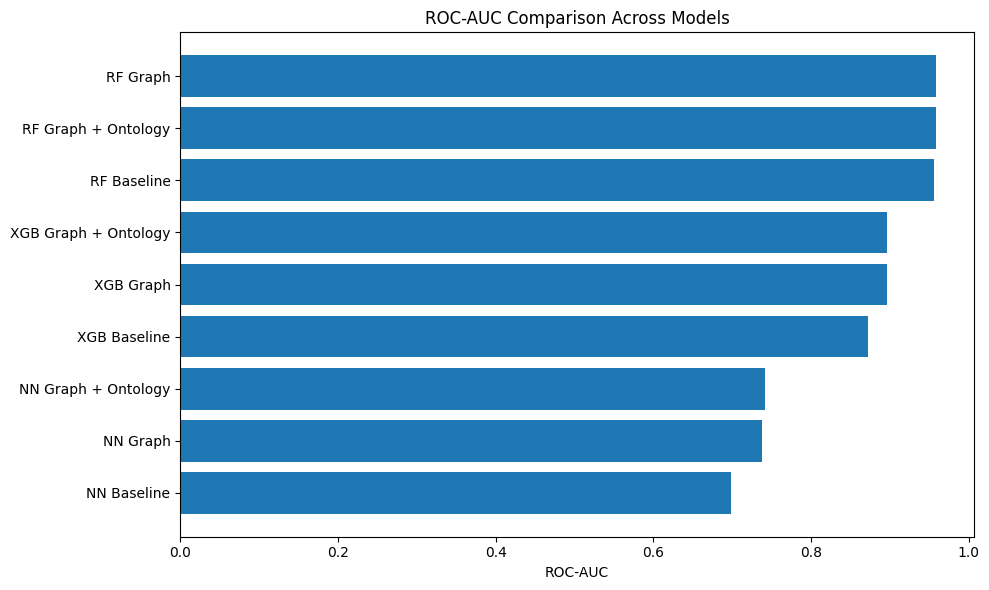

In [30]:
# ROC-AUC comparison.
plt.figure(figsize=(10, 6))
plt.barh(results["model"], results["roc_auc"])
plt.xlabel("ROC-AUC")
plt.title("ROC-AUC Comparison Across Models")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_auc_comparison.png", dpi=300)
plt.show()

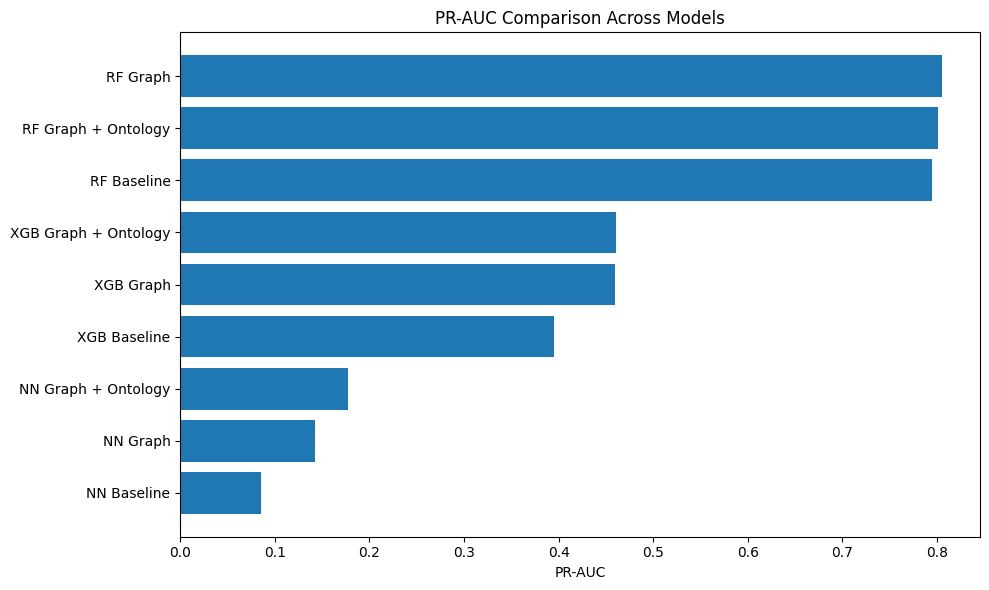

In [31]:
# PR-AUC comparison.
plt.figure(figsize=(10, 6))
plt.barh(results["model"], results["pr_auc"])
plt.xlabel("PR-AUC")
plt.title("PR-AUC Comparison Across Models")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pr_auc_comparison.png", dpi=300)
plt.show()

## 19. ROC and Precision-Recall Curves

The curves below compare the best model family across baseline, graph-enhanced and ontology-enhanced settings.


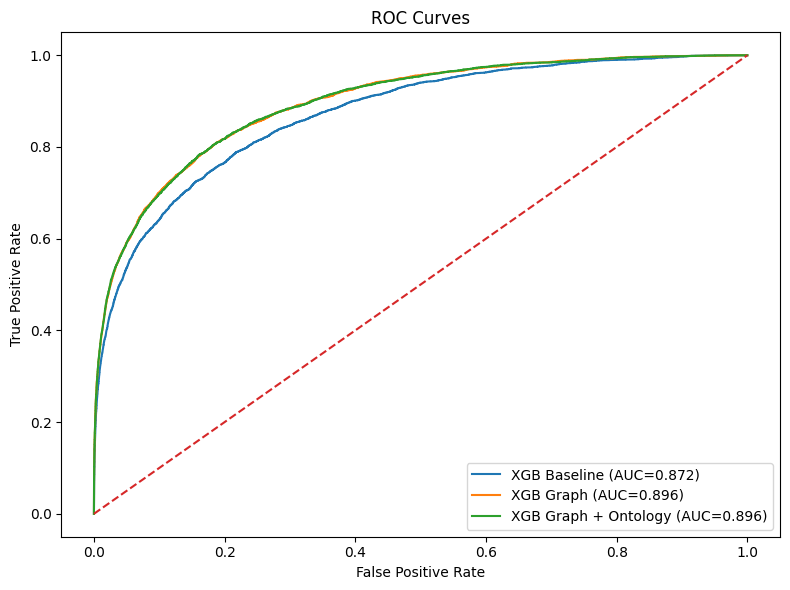

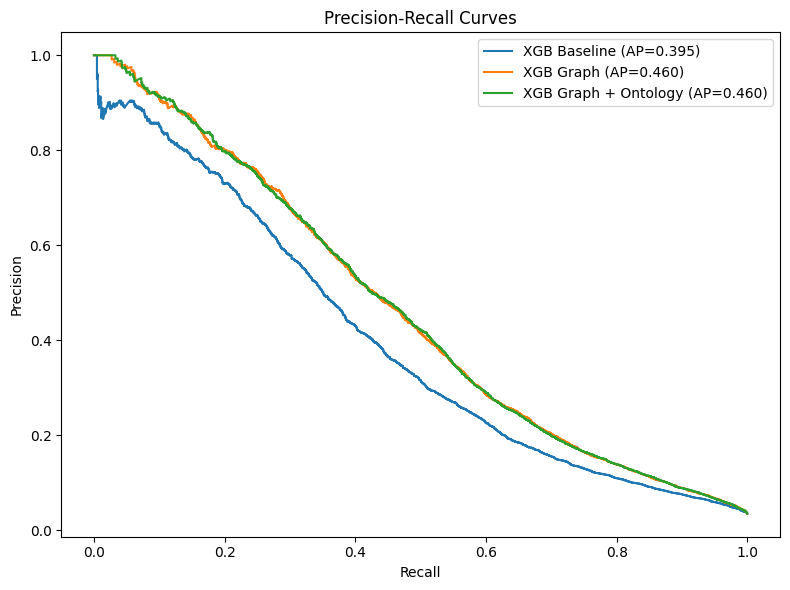

In [32]:
def plot_roc_curves(curves, y_true, output_path=None):
    plt.figure(figsize=(8, 6))

    for label, probs in curves.items():
        fpr, tpr, _ = roc_curve(y_true, probs)
        auc_score = roc_auc_score(y_true, probs)
        plt.plot(fpr, tpr, label=f"{label} (AUC={auc_score:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend()
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=300)

    plt.show()


def plot_pr_curves(curves, y_true, output_path=None):
    plt.figure(figsize=(8, 6))

    for label, probs in curves.items():
        precision, recall, _ = precision_recall_curve(y_true, probs)
        ap_score = average_precision_score(y_true, probs)
        plt.plot(recall, precision, label=f"{label} (AP={ap_score:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curves")
    plt.legend()
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=300)

    plt.show()


xgb_curves = {
    "XGB Baseline": xgb_baseline_probs,
    "XGB Graph": xgb_graph_probs,
    "XGB Graph + Ontology": xgb_graph_ontology_probs
}

plot_roc_curves(xgb_curves, y_test, OUTPUT_DIR / "xgb_roc_curves.png")
plot_pr_curves(xgb_curves, y_test, OUTPUT_DIR / "xgb_pr_curves.png")

## 20. Feature Importance

Feature importance helps explain which variables influenced the tree-based models.

This is useful for the explainability section and Chapter 4/5 discussion.

In [33]:
def get_feature_importance(model, feature_names, top_n=30):
    """Return top feature importances for tree-based models."""
    importance = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    })

    return importance.sort_values("importance", ascending=False).head(top_n)


# Random Forest graph + ontology feature importance.
rf_go_importance = get_feature_importance(
    rf_graph_ontology,
    graph_ontology_feature_names,
    top_n=30
)

rf_go_importance

,feature,importance
1,TransactionDT,0.104525
0,TransactionAmt,0.095890
46,ontology_risk_score,0.095508
34,pagerank,0.093197
36,max_entity_fraud_rate,0.087638
6,addr1,0.052951
2,card1,0.051699
8,dist1,0.044594
3,card2,0.040824
50,P_emaildomain,0.031359


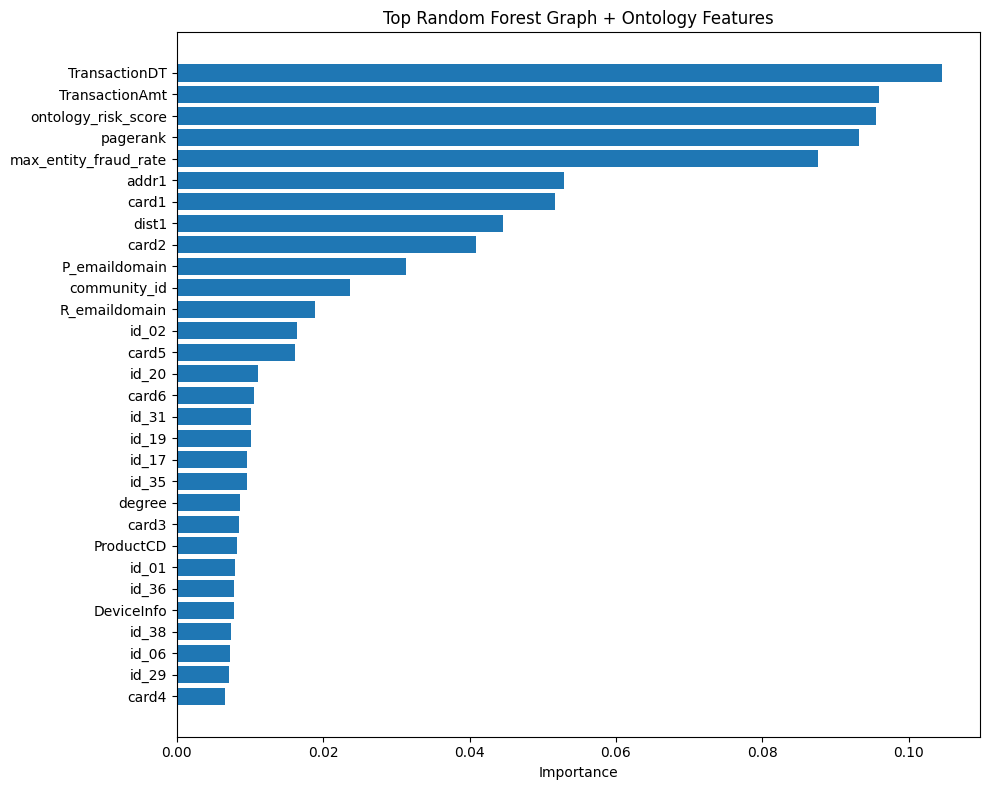

In [34]:
plt.figure(figsize=(10, 8))
plt.barh(rf_go_importance["feature"], rf_go_importance["importance"])
plt.xlabel("Importance")
plt.title("Top Random Forest Graph + Ontology Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rf_graph_ontology_feature_importance.png", dpi=300)
plt.show()

## 21. Confusion Matrices

Confusion matrices show the number of:

- true negatives,
- false positives,
- false negatives,
- true positives.

These are useful for explaining the practical fraud-investigation trade-off.

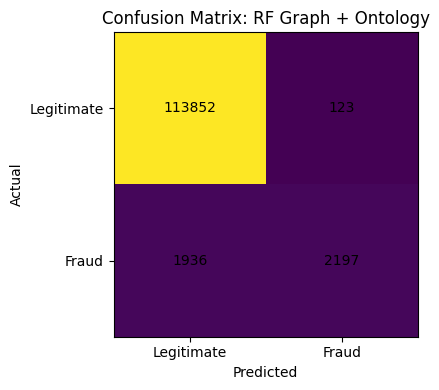

In [35]:
def plot_confusion_matrix(y_true, probs, model_name, threshold=0.50, output_path=None):
    preds = (probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, preds)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0, 1], ["Legitimate", "Fraud"])
    plt.yticks([0, 1], ["Legitimate", "Fraud"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=300)

    plt.show()


plot_confusion_matrix(
    y_test,
    rf_graph_ontology_probs,
    "RF Graph + Ontology",
    threshold=0.50,
    output_path=OUTPUT_DIR / "rf_graph_ontology_confusion_matrix.png"
)

## 22. Human-Readable Explainability Demo

This section generates practical investigation-style explanations.

The aim is to demonstrate how graph and ontology features can make model outputs easier for a non-technical analyst to understand.

In [36]:
def risk_band(prob):
    """Convert model fraud probability into a user-friendly risk band."""
    if prob >= 0.90:
        return "Very high risk"
    elif prob >= 0.75:
        return "High risk"
    elif prob >= 0.50:
        return "Medium risk"
    elif prob >= 0.25:
        return "Low risk"
    else:
        return "Very low risk"


def explain_transaction(row, reference_df):
    """Generate plain-English reasons for why a transaction may be risky."""
    reasons = []

    if row.get("pellet_requires_investigation", 0) == 1:
        reasons.append("Pellet reasoning inferred that this transaction requires investigation.")

    if row.get("requires_investigation", 0) == 1:
        reasons.append("Ontology rules marked this transaction as requiring investigation.")

    if row.get("uses_high_risk_entity", 0) == 1:
        reasons.append("The transaction is linked to at least one high-risk entity.")

    if row.get("has_multiple_high_risk_entities", 0) == 1:
        reasons.append(
            f"The transaction is linked to {int(row.get('high_risk_entity_count', 0))} high-risk entities."
        )

    if row.get("max_entity_fraud_rate", 0) >= ENTITY_HIGH_RISK_THRESHOLD:
        reasons.append(
            f"The riskiest linked entity has a historical fraud rate of {row.get('max_entity_fraud_rate', 0):.1%}."
        )

    if "pagerank" in row.index and row.get("pagerank", 0) > reference_df["pagerank"].median():
        reasons.append("The transaction has above-median PageRank, suggesting graph centrality.")

    if "degree" in row.index and row.get("degree", 0) > reference_df["degree"].median():
        reasons.append("The transaction has above-median graph degree, suggesting repeated shared connections.")

    if "community_id" in row.index and row.get("community_id", 0) != 0:
        reasons.append(f"The transaction belongs to graph community {int(row.get('community_id', 0))}.")

    if row.get("ontology_risk_score", 0) >= 0.50:
        reasons.append(
            f"The ontology risk score is elevated at {row.get('ontology_risk_score', 0):.2f}."
        )

    if "degree" in reference_df.columns and row.get("degree", 0) > reference_df["degree"].median():
        reasons.append("The transaction is connected to a high number of graph entities, indicating strong network involvement.")

    if not reasons:
        reasons.append("No strong semantic reason was triggered, but the model still assigned this probability based on combined feature patterns.")

    return reasons


def build_transaction_note(row, reference_df):
    """Create a report-style explanation for a single transaction."""
    reasons = explain_transaction(row, reference_df)

    note = []
    note.append(f"Transaction ID: {row['TransactionID']}")
    note.append(f"Risk band: {risk_band(row['fraud_probability'])}")
    note.append(f"Predicted fraud probability: {row['fraud_probability']:.1%}")
    note.append(f"Actual label in test data: {int(row['actual_isFraud'])}")
    note.append("")
    note.append("Main reasons:")

    for reason in reasons:
        note.append(f"- {reason}")

    if row["fraud_probability"] >= 0.75:
        note.append("")
        note.append("Suggested action: Review before approval or escalation.")
    elif row["fraud_probability"] >= 0.50:
        note.append("")
        note.append("Suggested action: Monitor or review if additional risk signals are present.")
    else:
        note.append("")
        note.append("Suggested action: Low priority unless other business rules are triggered.")

    return "\n".join(note)


In [37]:
# Build explanation cases using the graph + ontology test dataframe.
# Here Random Forest Graph + Ontology is used; swap probabilities if another model performs best.
xai_cases = test_ontology_df.copy()
xai_cases["fraud_probability"] = rf_graph_ontology_probs
xai_cases["actual_isFraud"] = y_test.values
xai_cases["risk_band"] = xai_cases["fraud_probability"].apply(risk_band)

# Sample varied cases across risk bands rather than only the most extreme fraud probabilities.
varied_cases = (
    xai_cases
    .groupby("risk_band", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 3), random_state=RANDOM_STATE))
    .sort_values("fraud_probability", ascending=False)
)

report_rows = []

for _, row in varied_cases.iterrows():
    report_rows.append({
        "TransactionID": row["TransactionID"],
        "risk_band": row["risk_band"],
        "fraud_probability": row["fraud_probability"],
        "actual_isFraud": row["actual_isFraud"],
        "community_id": row.get("community_id", 0),
        "pagerank": row.get("pagerank", 0),
        "degree": row.get("degree", 0),
        "max_entity_fraud_rate": row.get("max_entity_fraud_rate", 0),
        "high_risk_entity_count": row.get("high_risk_entity_count", 0),
        "pellet_requires_investigation": row.get("pellet_requires_investigation", 0),
        "ontology_risk_score": row.get("ontology_risk_score", 0),
        "layman_summary": build_transaction_note(row, xai_cases)
    })

xai_report_df = pd.DataFrame(report_rows)
xai_report_df


C:\Users\Osman\AppData\Local\Temp\ipykernel_24516\2736206974.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 3), random_state=RANDOM_STATE))


,TransactionID,risk_band,fraud_probability,actual_isFraud,community_id,pagerank,degree,max_entity_fraud_rate,high_risk_entity_count,pellet_requires_investigation,ontology_risk_score,layman_summary
0,3208782,Very high risk,1.000000,1,283,0.512788,10,0.602564,2,1,0.581538,Transaction ID: 3208782\nRisk band: Very high ...
1,3121894,Very high risk,1.000000,1,1092,0.662188,15,0.765957,3,1,0.739574,Transaction ID: 3121894\nRisk band: Very high ...
2,3186621,Very high risk,0.906667,1,283,0.504525,10,0.066942,0,0,0.040165,Transaction ID: 3186621\nRisk band: Very high ...
3,3387754,High risk,0.830000,1,1092,0.660674,15,0.218750,0,0,0.131250,Transaction ID: 3387754\nRisk band: High risk\...
4,3186493,High risk,0.790000,1,865,0.512934,10,0.043590,0,0,0.026154,Transaction ID: 3186493\nRisk band: High risk\...
5,3219594,High risk,0.756667,1,31055,0.521677,11,0.295486,0,0,0.177291,Transaction ID: 3219594\nRisk band: High risk\...
6,3145410,Medium risk,0.710000,1,31055,0.562502,12,0.382353,0,0,0.229412,Transaction ID: 3145410\nRisk band: Medium ris...
7,3166829,Medium risk,0.663333,1,283,0.688761,16,0.118917,0,0,0.071350,Transaction ID: 3166829\nRisk band: Medium ris...
8,3372892,Medium risk,0.560000,1,1092,0.677591,16,0.181818,0,0,0.109091,Transaction ID: 3372892\nRisk band: Medium ris...
9,3307105,Low risk,0.440000,1,762,0.514292,10,0.043590,0,0,0.026154,Transaction ID: 3307105\nRisk band: Low risk\n...


In [38]:
# Print readable reports.
for summary in xai_report_df["layman_summary"]:
    print("=" * 90)
    print(summary)
    print()

Transaction ID: 3208782
Risk band: Very high risk
Predicted fraud probability: 100.0%
Actual label in test data: 1

Main reasons:
- Pellet reasoning inferred that this transaction requires investigation.
- Ontology rules marked this transaction as requiring investigation.
- The transaction is linked to at least one high-risk entity.
- The transaction is linked to 2 high-risk entities.
- The riskiest linked entity has a historical fraud rate of 60.3%.
- The transaction has above-median PageRank, suggesting graph centrality.
- The transaction belongs to graph community 283.
- The ontology risk score is elevated at 0.58.

Suggested action: Review before approval or escalation.

Transaction ID: 3121894
Risk band: Very high risk
Predicted fraud probability: 100.0%
Actual label in test data: 1

Main reasons:
- Pellet reasoning inferred that this transaction requires investigation.
- Ontology rules marked this transaction as requiring investigation.
- The transaction is linked to at least one

In [39]:
# Save explanation report for dissertation appendix or demo.
xai_report_df.to_csv(OUTPUT_DIR / "human_readable_xai_report.csv", index=False)
print("Saved:", OUTPUT_DIR / "human_readable_xai_report.csv")

Saved: outputs\human_readable_xai_report.csv


## 23. Save Final Predictions

This saves model probabilities for later analysis, plots and dissertation evidence.

In [40]:
predictions = pd.DataFrame({
    "TransactionID": test_df["TransactionID"].values,
    "actual_isFraud": y_test.values,

    "rf_baseline_prob": rf_baseline_probs,
    "rf_graph_prob": rf_graph_probs,
    "rf_graph_ontology_prob": rf_graph_ontology_probs,

    "xgb_baseline_prob": xgb_baseline_probs,
    "xgb_graph_prob": xgb_graph_probs,
    "xgb_graph_ontology_prob": xgb_graph_ontology_probs,

    "nn_baseline_prob": baseline_nn_probs,
    "nn_graph_prob": graph_nn_probs,
    "nn_graph_ontology_prob": graph_ontology_nn_probs,
})

# Save prediction outputs.
predictions.to_csv(OUTPUT_DIR / "final_model_predictions.csv", index=False)

# Save the exact graph + ontology feature table used for the held-out test set.
test_feature_audit = test_ontology_df[["TransactionID"] + graph_features + ontology_features].copy()
test_feature_audit.to_csv(OUTPUT_DIR / "test_graph_ontology_feature_audit.csv", index=False)

print("Saved:", OUTPUT_DIR / "final_model_predictions.csv")
print("Saved:", OUTPUT_DIR / "test_graph_ontology_feature_audit.csv")


Saved: outputs\final_model_predictions.csv
Saved: outputs\test_graph_ontology_feature_audit.csv
